![Index and embed_260623_124023_1.jpg](<attachment:Index and embed_260623_124023_1.jpg>)
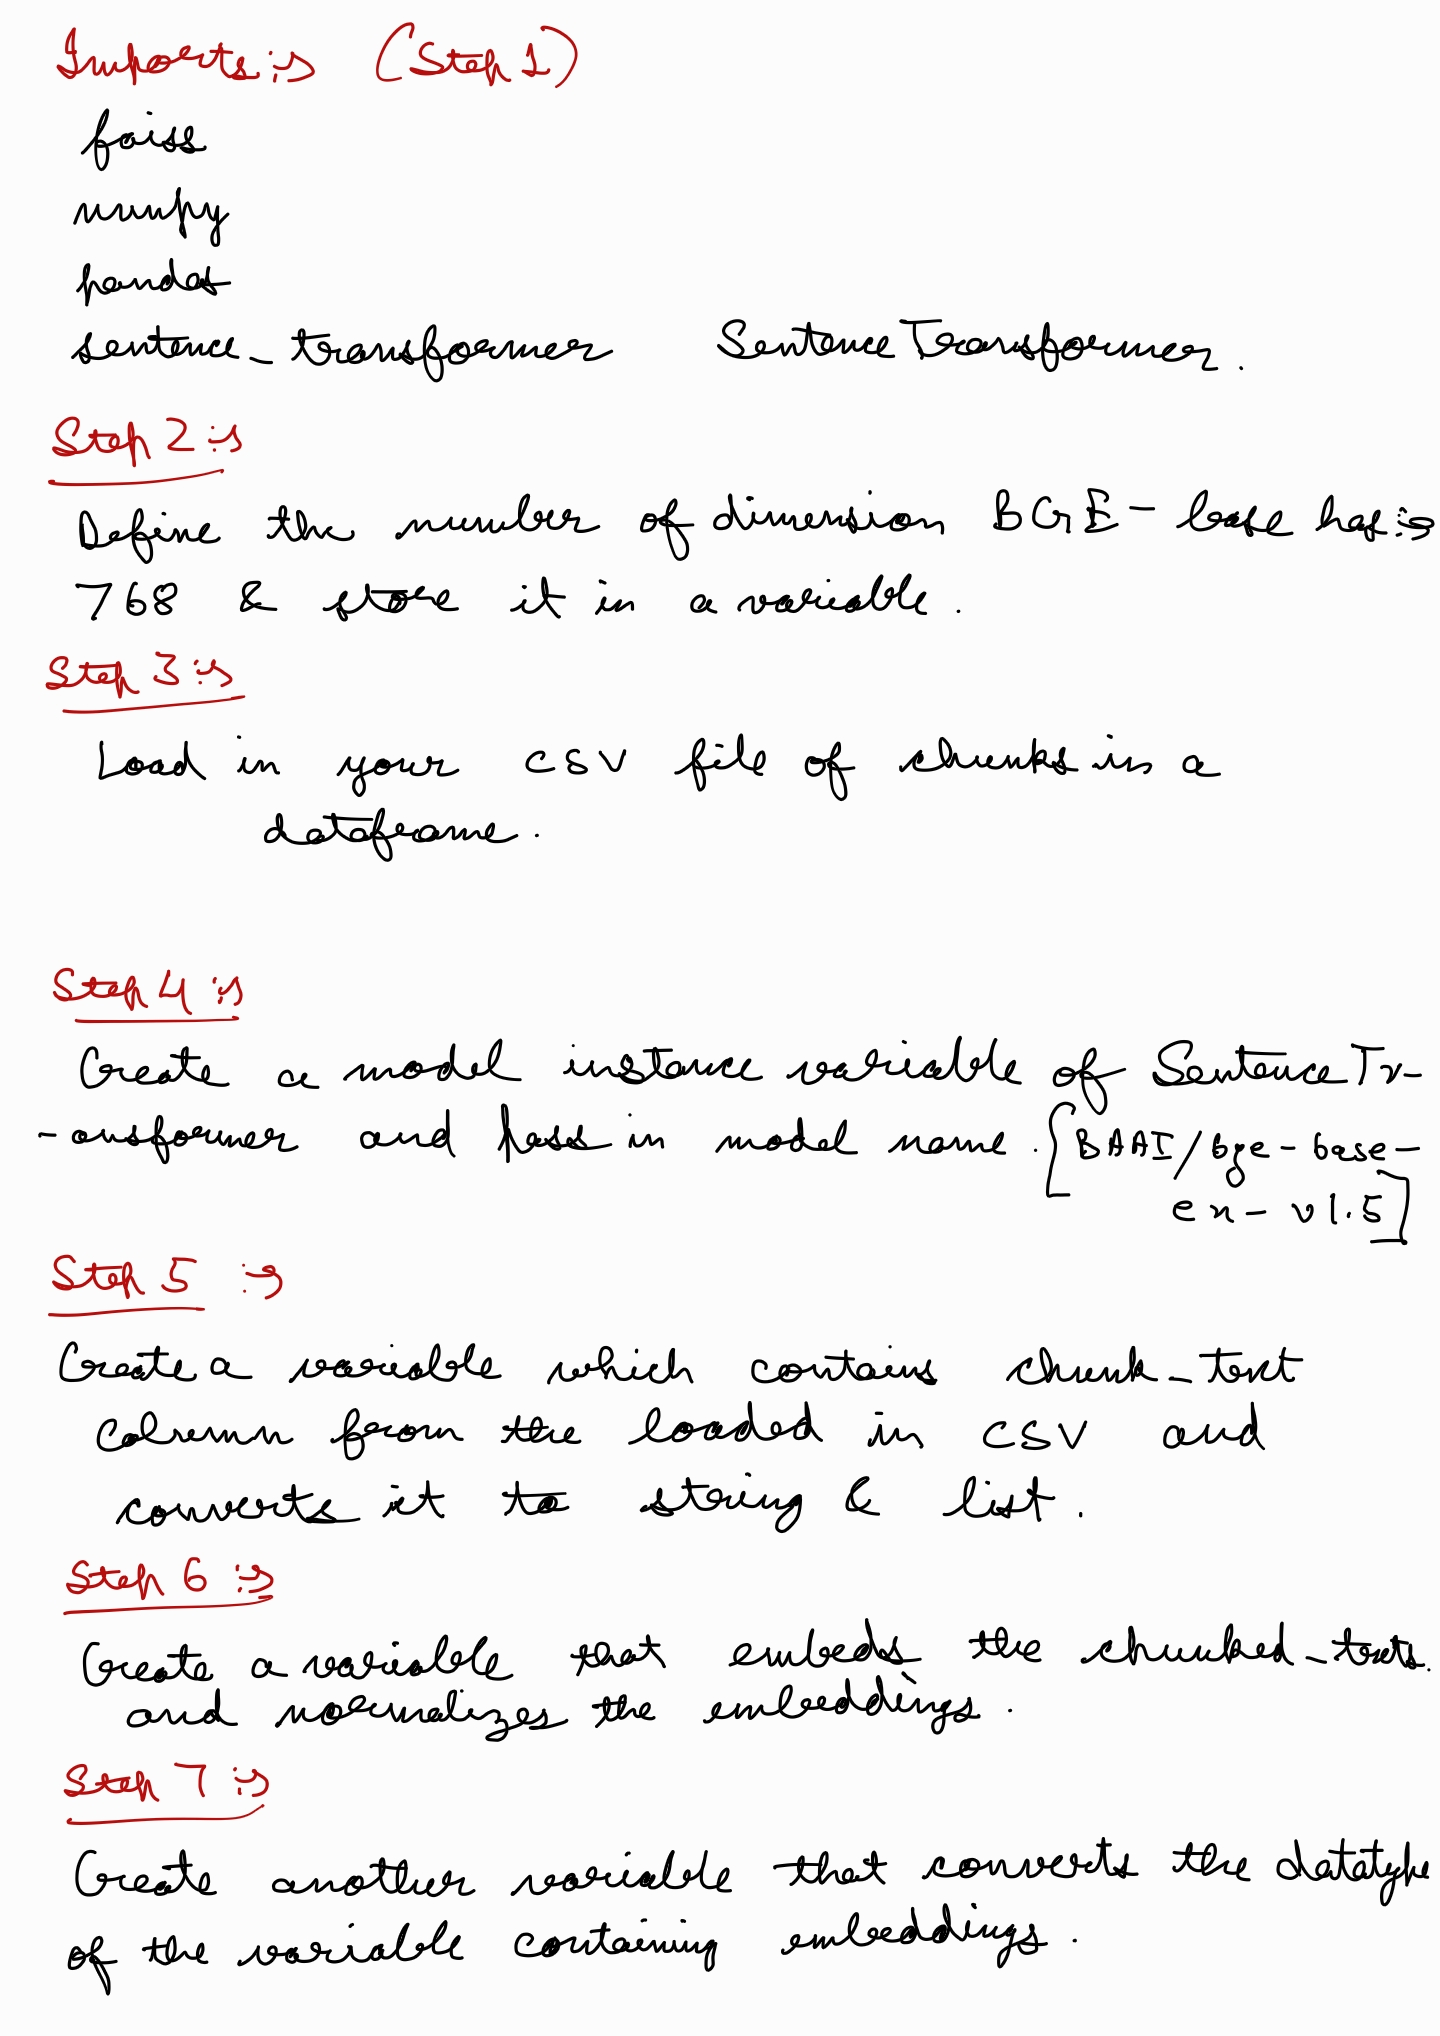

![Index and embed_260623_124023_2.jpg](<attachment:Index and embed_260623_124023_2.jpg>)
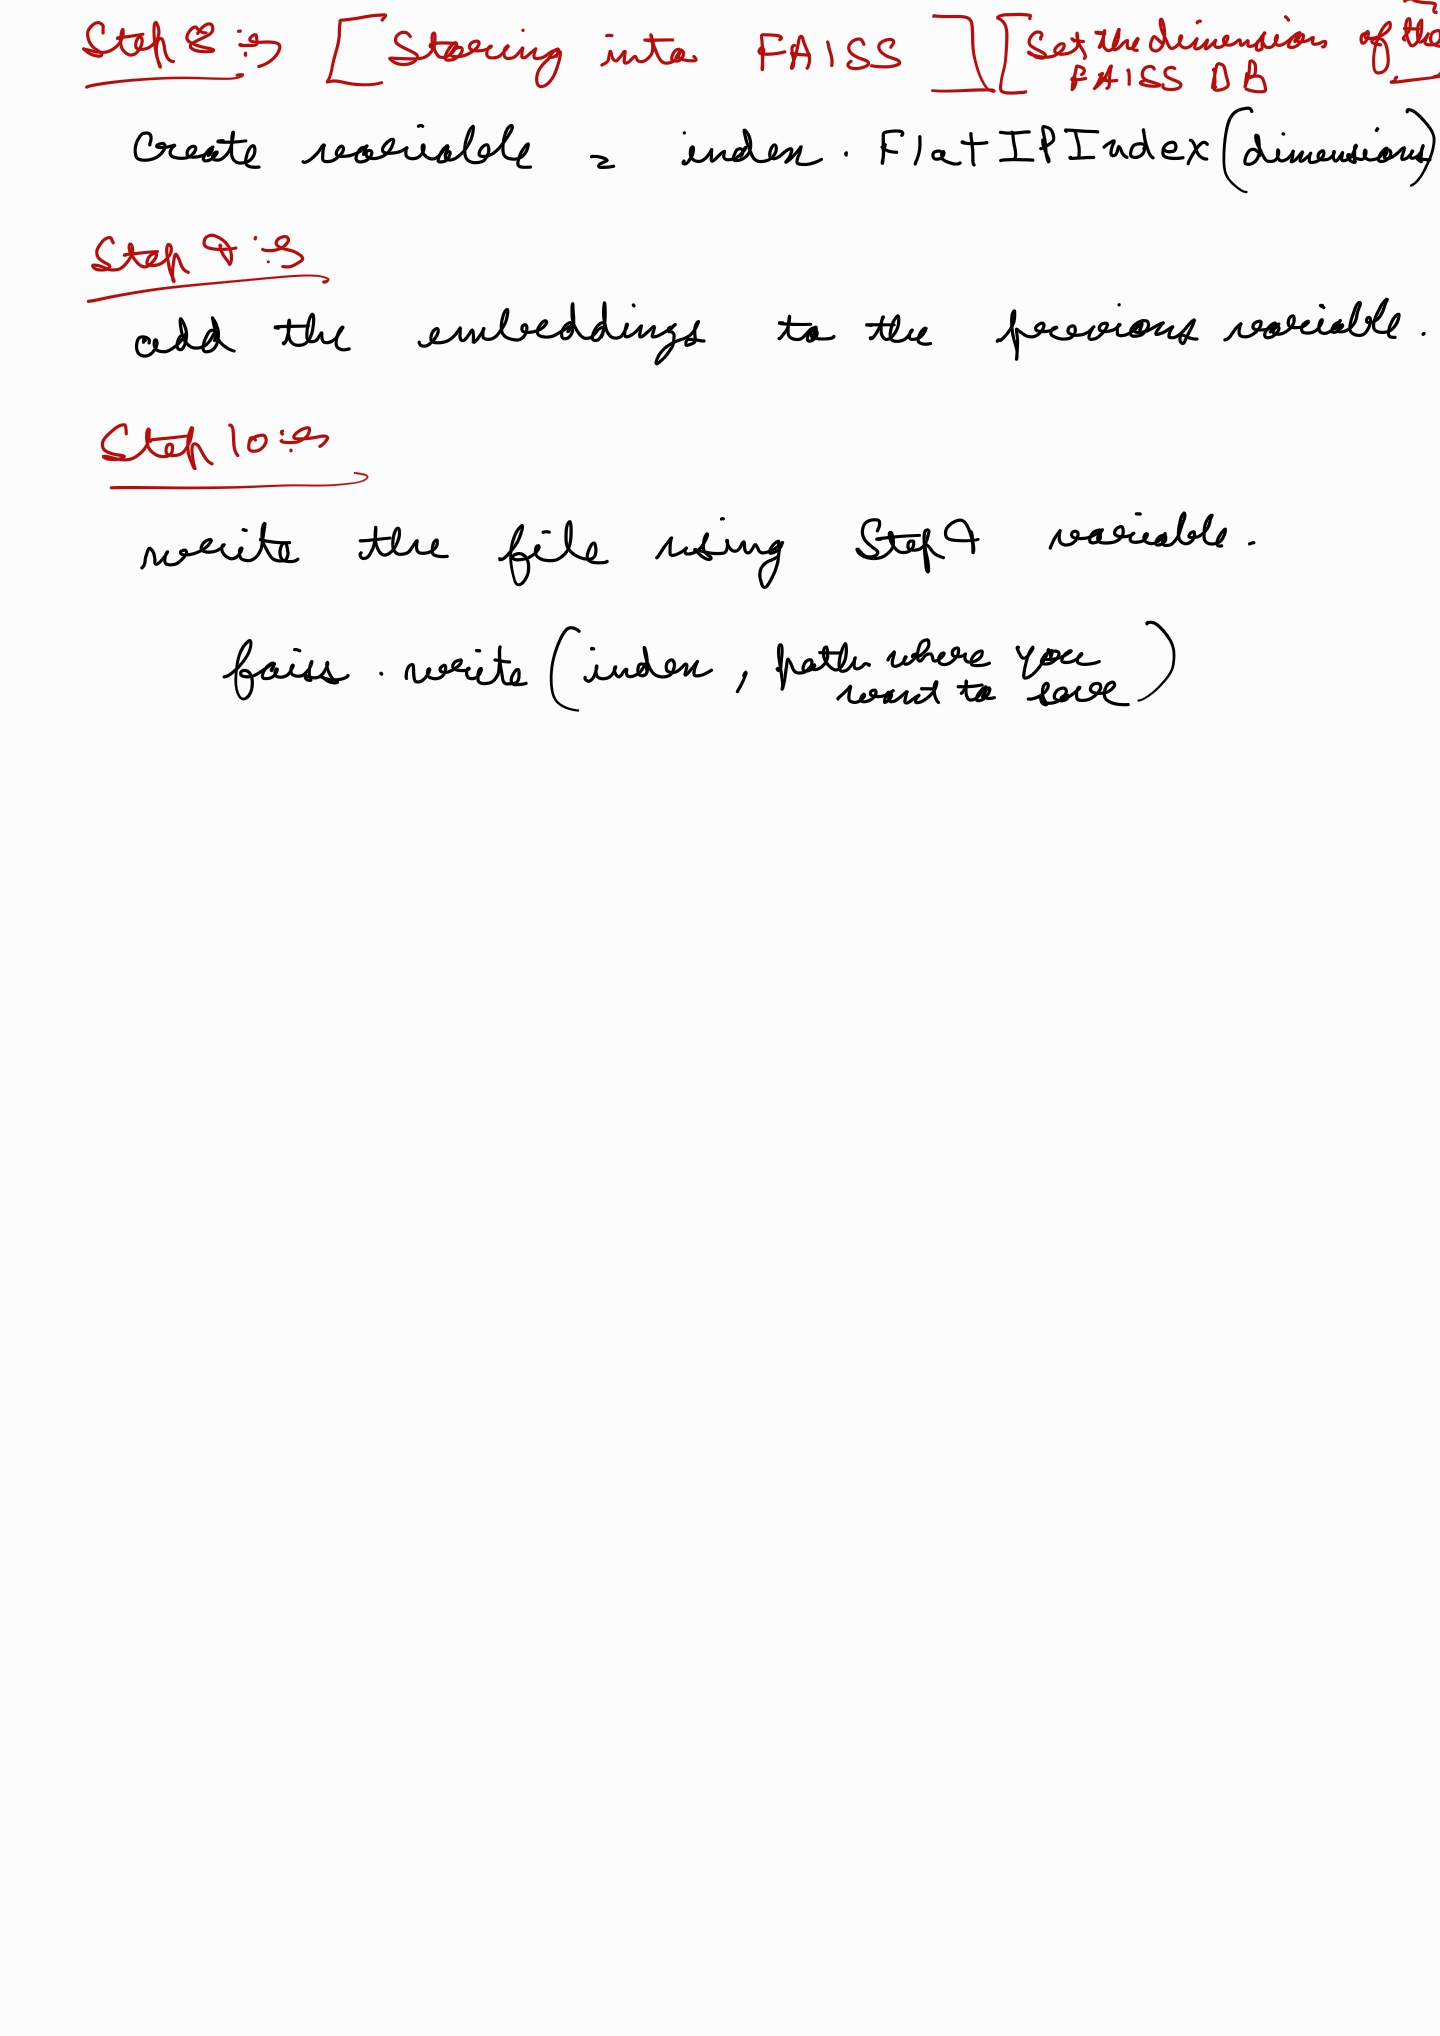

In [3]:
import numpy as np
import faiss
import pandas as pd
from sentence_transformers import SentenceTransformer

In [ ]:
dim_size=768 #This is for FAISS actually
df=pd.read_csv("../../data/chunked/langChainchunks.csv")
model=SentenceTransformer("BAAI/bge-base-en-v1.5")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2446.89it/s]


In [ ]:
full_chunks=df["chunk_text"].astype(str).tolist()
# Sanity check:- 
# print(len(full_chunks))
# print(full_chunks[1793])

1794
with precision, maximizing output. Get started with Mission Control Mission Control 3.0 is designed around minimizing inefficiencies and increasing token output for AI factory operators. By correlating telemetry across domains, orchestrating power intelligently, modularizing the architecture for agility, and enhancing autonomous remediation with AI, it transforms infrastructure from a passive platform into an active participant in performance optimization. Resources: Stay tuned for our latest release notes and implementation guides for NVIDIA Mission Control 3.0. You can also check out the on-demand replay for the NVIDIA GTC 2026 session with Eli Lilly & Company to hear firsthand insights into architecting and deploying high-performance AI infrastructure with powerful, intelligent software.


In [11]:
embs=model.encode(full_chunks, normalize_embeddings=True, show_progress_bar=True, batch_size=40)
float32_embs=embs.astype("float32")

Batches: 100%|██████████| 45/45 [23:16<00:00, 31.02s/it]


In [ ]:
var=faiss.IndexFlatIP(dim_size)
var.add(float32_embs)

In [13]:
print("Vectors in total are: ", var.ntotal)

Vectors in total are:  1794


### Meta data:-
- We know that FAISS only stores vectors for chunks.
- Due to this, we have to store the metadata in a separate csv file.
- To do that, we take a new dataframe and copy the fields we want from the old dataframe.
- Fields we want from the old dataframe is:-
    - ["chunk_id", "source", "title", "url", "published", "chunk_text"]
- Just copy these into the new dataframe.


In [14]:
metadata_df=df[["chunk_id", "source", "title", "url", "published", "chunk_text"]].copy()

### Save both the files:-
- Both csv for metadata and .index file for embeddings.

In [ ]:
# Now just save the file using:- faiss.write_index(variable_name_containing_embs, location where you want to save it)
# Alwas keep in mind that the embeddings file for faiss must always be saved with a .index extension
faiss.write_index(var, "../../data/embeddings/nvidia_faiss.index")
metadata_df.to_csv("../../data/embeddings/nvidia_faiss_metadata.csv", index=False)